### Battery SOC notebook

First step: inspect the raw battery charge and discharge data before doing any SOC calculations.

#### Load the raw data

This cell only reads the two CSV files and checks what is inside them. The plots use the raw logged columns so we can see if the data looks reasonable before treating it.

Charge data shape: (56108, 10)
Discharge data shape: (78477, 10)

Columns:
['pc_time', 'elapsed_s', 'bus_V', 'current_mA', 'power_mW', 'shunt_mV', 'voltage_corrected_V', 'soc_voltage_percent', 'soc_percent', 'mode']

First charge rows:


,pc_time,elapsed_s,bus_V,current_mA,power_mW,shunt_mV,voltage_corrected_V,soc_voltage_percent,soc_percent,mode
0,2026-04-20 18:09:02.387,0.001,0.0012,-0.025,0.0,-0.0025,0.0013,0.0,0.0,REST
1,2026-04-20 18:09:02.388,0.002,0.0012,-0.025,0.0,-0.0025,0.0013,0.0,0.0,REST
2,2026-04-20 18:09:02.972,0.587,0.0012,-0.025,0.0,-0.0025,0.0013,0.0,0.0,REST
3,2026-04-20 18:09:03.974,1.589,0.0000,-0.025,0.0,-0.0025,0.0000,0.0,0.0,REST
4,2026-04-20 18:09:04.976,2.590,0.0012,-0.025,0.0,-0.0025,0.0013,0.0,0.0,REST



First discharge rows:


,pc_time,elapsed_s,bus_V,current_mA,power_mW,shunt_mV,voltage_corrected_V,soc_voltage_percent,soc_percent,mode
0,2026-04-21 09:57:17.740,0.001,4.3325,0.000,0.0,0.0000,4.3325,82.31,82.31,REST
1,2026-04-21 09:57:17.741,0.002,4.3337,-0.025,0.0,-0.0025,4.3338,82.31,82.31,REST
2,2026-04-21 09:57:18.039,0.300,4.3337,-0.025,0.0,-0.0025,4.3338,82.31,82.31,REST
3,2026-04-21 09:57:19.042,1.303,4.3337,-0.025,0.0,-0.0025,4.3338,82.31,82.31,REST
4,2026-04-21 09:57:20.046,2.307,4.3325,-0.025,0.0,-0.0025,4.3325,82.31,82.31,REST


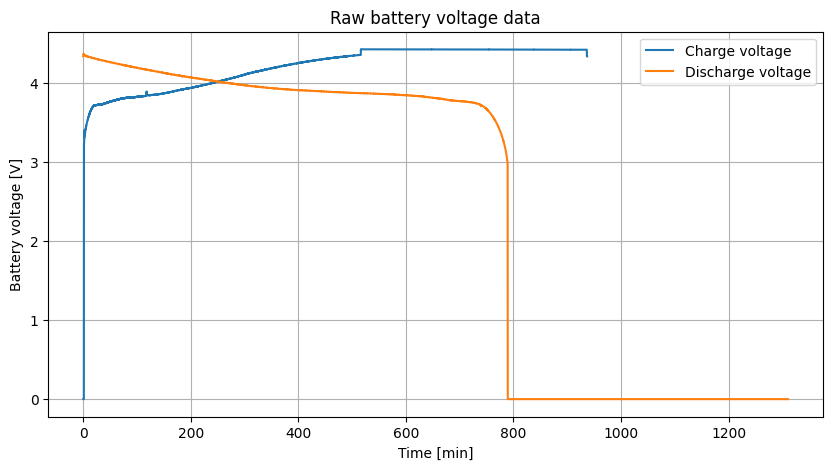

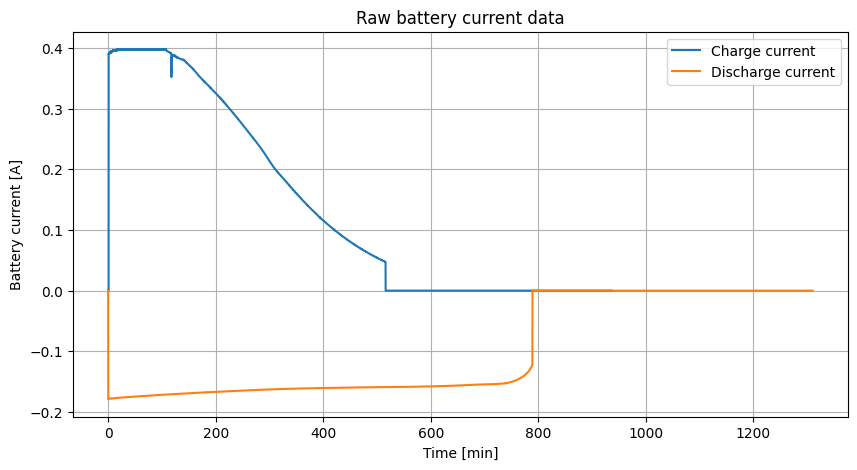

In [6]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


DATA_DIR = Path("../../data/Battery_test")

CHARGE_FILE = "BATTERY_CHARGE_ina226_soc_log_20260420_180900.csv"
DISCHARGE_FILE = "BATTERY_DISCHARGE_ina226_soc_log_20260421_095715.csv"


charge_raw = pd.read_csv(DATA_DIR / CHARGE_FILE)
discharge_raw = pd.read_csv(DATA_DIR / DISCHARGE_FILE)

print("Charge data shape:", charge_raw.shape)
print("Discharge data shape:", discharge_raw.shape)

print("\nColumns:")
print(charge_raw.columns.tolist())

print("\nFirst charge rows:")
display(charge_raw.head())

print("\nFirst discharge rows:")
display(discharge_raw.head())


plt.figure(figsize=(10, 5))
plt.plot(charge_raw["elapsed_s"] / 60, charge_raw["voltage_corrected_V"], label="Charge voltage")
plt.plot(discharge_raw["elapsed_s"] / 60, discharge_raw["voltage_corrected_V"], label="Discharge voltage")
plt.xlabel("Time [min]")
plt.ylabel("Battery voltage [V]")
plt.title("Raw battery voltage data")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(charge_raw["elapsed_s"] / 60, charge_raw["current_mA"] / 1000, label="Charge current")
plt.plot(discharge_raw["elapsed_s"] / 60, discharge_raw["current_mA"] / 1000, label="Discharge current")
plt.xlabel("Time [min]")
plt.ylabel("Battery current [A]")
plt.title("Raw battery current data")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
print("Charge modes:")
print(charge_raw["mode"].value_counts())

print("\nDischarge modes:")
print(discharge_raw["mode"].value_counts())


# Thresholds are in mA.
# They remove the REST parts where the sensor is close to 0 A.
charge_current_threshold_mA = 50
discharge_current_threshold_mA = -50

charge = charge_raw[
    charge_raw["current_mA"] > charge_current_threshold_mA
].copy()

discharge = discharge_raw[
    discharge_raw["current_mA"] < discharge_current_threshold_mA
].copy()

# Reset time so the selected active periods start at 0 minutes.
charge["time_charge_min"] = (
    charge["elapsed_s"] - charge["elapsed_s"].iloc[0]
) / 60

discharge["time_discharge_min"] = (
    discharge["elapsed_s"] - discharge["elapsed_s"].iloc[0]
) / 60

print("\nSelected charge rows:", len(charge))
print("Selected discharge rows:", len(discharge))

display(charge.head())
display(discharge.head())


Charge modes:
mode
CHARGE    30846
REST      25262
Name: count, dtype: int64

Discharge modes:
mode
DISCHARGE    47246
REST         31231
Name: count, dtype: int64

Selected charge rows: 30459
Selected discharge rows: 47246


,pc_time,elapsed_s,bus_V,current_mA,power_mW,shunt_mV,voltage_corrected_V,soc_voltage_percent,soc_percent,mode,time_charge_min
54,2026-04-20 18:09:55.085,52.700,3.5538,389.725,1385.000,38.9725,3.1414,0.61,0.01,CHARGE,0.000000
55,2026-04-20 18:09:56.088,53.702,3.5725,390.250,1394.375,39.0250,3.1596,0.68,0.01,CHARGE,0.016700
56,2026-04-20 18:09:57.090,54.704,3.5787,390.150,1396.250,39.0150,3.1660,0.70,0.02,CHARGE,0.033400
57,2026-04-20 18:09:58.091,55.706,3.5838,389.800,1396.875,38.9800,3.1713,0.72,0.02,CHARGE,0.050100
58,2026-04-20 18:09:59.093,56.707,3.5887,390.200,1400.625,39.0050,3.1759,0.74,0.03,CHARGE,0.066783


,pc_time,elapsed_s,bus_V,current_mA,power_mW,shunt_mV,voltage_corrected_V,soc_voltage_percent,soc_percent,mode,time_discharge_min
15,2026-04-21 09:57:31.076,13.336,4.1775,-178.750,746.250,-17.8750,4.3666,82.31,82.30,DISCHARGE,0.000000
16,2026-04-21 09:57:32.076,14.337,4.1762,-178.850,746.875,-17.8850,4.3655,82.31,82.30,DISCHARGE,0.016683
17,2026-04-21 09:57:33.076,15.337,4.1762,-178.875,746.875,-17.8875,4.3655,82.31,82.30,DISCHARGE,0.033350
18,2026-04-21 09:57:34.083,16.344,4.1762,-178.750,746.250,-17.8750,4.3654,82.31,82.29,DISCHARGE,0.050133
19,2026-04-21 09:57:35.083,17.344,4.1750,-178.700,746.250,-17.8700,4.3641,82.31,82.29,DISCHARGE,0.066800


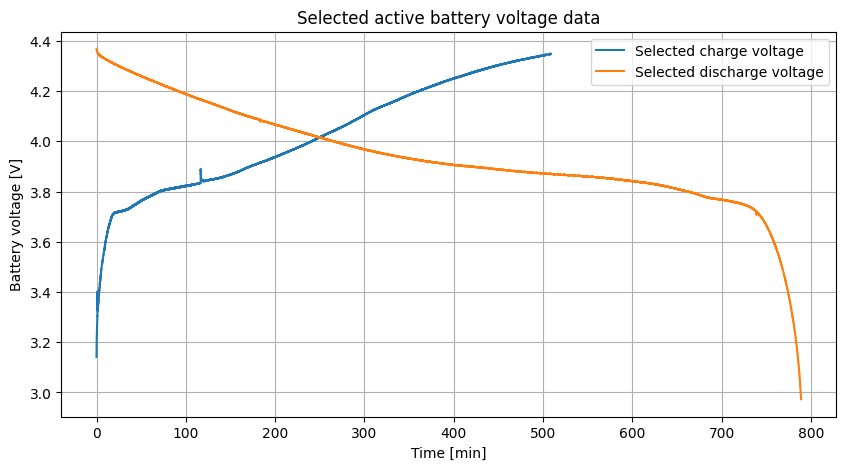

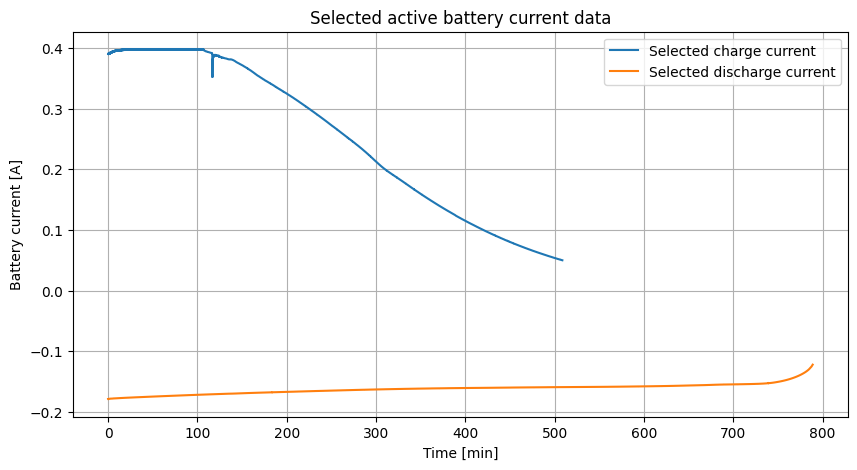

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    charge["time_charge_min"],
    charge["voltage_corrected_V"],
    label="Selected charge voltage",
)

plt.plot(
    discharge["time_discharge_min"],
    discharge["voltage_corrected_V"],
    label="Selected discharge voltage",
)

plt.xlabel("Time [min]")
plt.ylabel("Battery voltage [V]")
plt.title("Selected active battery voltage data")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    charge["time_charge_min"],
    charge["current_mA"] / 1000,
    label="Selected charge current",
)

plt.plot(
    discharge["time_discharge_min"],
    discharge["current_mA"] / 1000,
    label="Selected discharge current",
)

plt.xlabel("Time [min]")
plt.ylabel("Battery current [A]")
plt.title("Selected active battery current data")
plt.grid(True)
plt.legend()
plt.show()


Estimating state of charge 

In [9]:
# Convert current from mA to A.
discharge["current_A"] = discharge["current_mA"] / 1000

# Convert selected discharge time from minutes to hours.
discharge["time_h"] = discharge["time_discharge_min"] / 60

# Time step between each measurement, in hours.
discharge["dt_h"] = discharge["time_h"].diff().fillna(0)

# Discharge current is negative, so use abs() to get delivered current.
discharge["discharge_current_A"] = abs(discharge["current_A"])

# Charge removed during each small time step.
# Formula: dQ [Ah] = I [A] * dt [h]
discharge["removed_capacity_step_Ah"] = (
    discharge["discharge_current_A"]
    * discharge["dt_h"]
)

# Add all small steps to get removed capacity from the start of discharge.
discharge["removed_capacity_Ah"] = discharge["removed_capacity_step_Ah"].cumsum()

# Total measured capacity is the final removed capacity.
measured_capacity_Ah = discharge["removed_capacity_Ah"].iloc[-1]

# SOC starts at 100% and goes to 0% at the end of this discharge test.
# Formula: SOC [%] = 100 * (1 - removed_capacity_Ah / total_capacity_Ah)
discharge["soc_calculated_percent"] = (
    100
    * (1 - discharge["removed_capacity_Ah"] / measured_capacity_Ah)
)

print(f"Measured discharge capacity = {measured_capacity_Ah:.3f} Ah")

display(
    discharge[
        [
            "time_discharge_min",
            "voltage_corrected_V",
            "current_A",
            "removed_capacity_Ah",
            "soc_calculated_percent",
        ]
    ].head()
)


Measured discharge capacity = 2.126 Ah


,time_discharge_min,voltage_corrected_V,current_A,removed_capacity_Ah,soc_calculated_percent
15,0.000000,4.3666,-0.178750,0.000000,100.000000
16,0.016683,4.3655,-0.178850,0.000050,99.997661
17,0.033350,4.3655,-0.178875,0.000099,99.995324
18,0.050133,4.3654,-0.178750,0.000149,99.992973
19,0.066800,4.3641,-0.178700,0.000199,99.990638


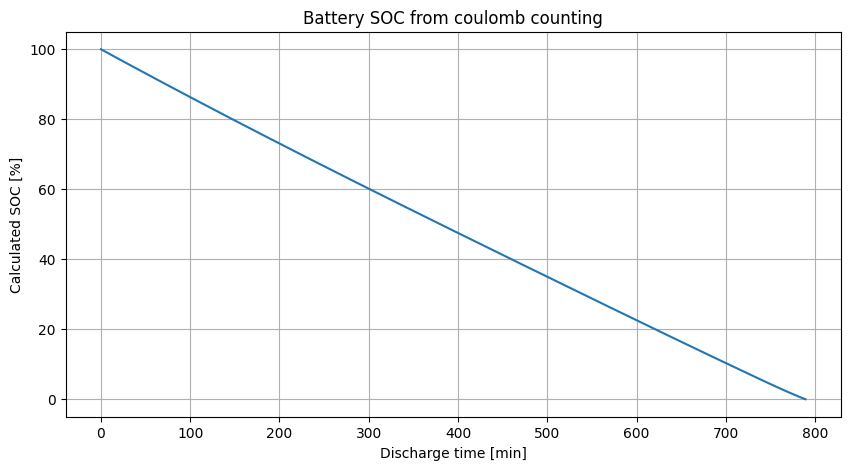

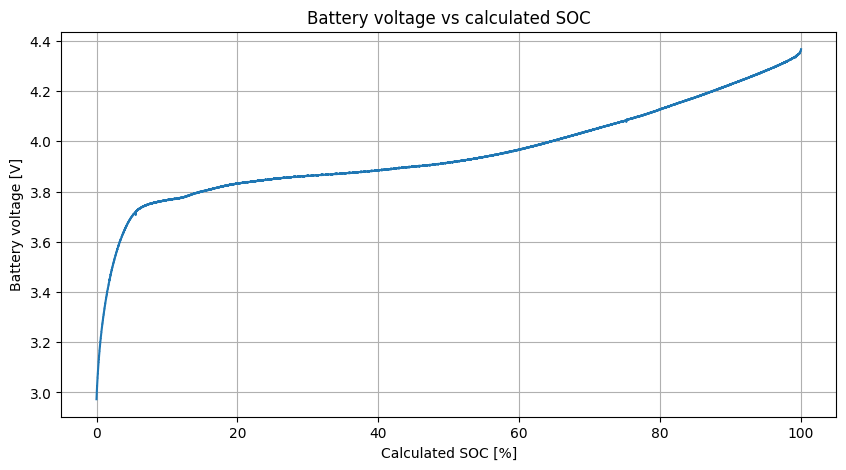

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    discharge["time_discharge_min"],
    discharge["soc_calculated_percent"],
)

plt.xlabel("Discharge time [min]")
plt.ylabel("Calculated SOC [%]")
plt.title("Battery SOC from coulomb counting")
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    discharge["soc_calculated_percent"],
    discharge["voltage_corrected_V"],
)

plt.xlabel("Calculated SOC [%]")
plt.ylabel("Battery voltage [V]")
plt.title("Battery voltage vs calculated SOC")
plt.grid(True)
plt.show()


In [11]:
# EMS battery size
EMS_BATTERY_CAPACITY_mWh = 100
EMS_BATTERY_CAPACITY_Wh = EMS_BATTERY_CAPACITY_mWh / 1000

# Battery discharge power
# Formula: P [W] = V [V] * I [A]
discharge["discharge_power_W"] = (
    discharge["voltage_corrected_V"]
    * discharge["discharge_current_A"]
)

# Energy removed during each time step
# Formula: dE [Wh] = P [W] * dt [h]
discharge["removed_energy_step_Wh"] = (
    discharge["discharge_power_W"]
    * discharge["dt_h"]
)

# Total removed energy from the real measured test
discharge["removed_energy_Wh"] = discharge["removed_energy_step_Wh"].cumsum()

measured_energy_Wh = discharge["removed_energy_Wh"].iloc[-1]

# Scale the measured battery down to the EMS battery size
energy_scale_factor = EMS_BATTERY_CAPACITY_Wh / measured_energy_Wh

discharge["ems_removed_energy_mWh"] = (
    discharge["removed_energy_Wh"]
    * energy_scale_factor
    * 1000
)

discharge["ems_remaining_energy_mWh"] = (
    EMS_BATTERY_CAPACITY_mWh
    - discharge["ems_removed_energy_mWh"]
)

discharge["ems_soc_percent"] = (
    100
    * discharge["ems_remaining_energy_mWh"]
    / EMS_BATTERY_CAPACITY_mWh
)

print(f"Measured battery energy = {measured_energy_Wh:.3f} Wh")
print(f"EMS battery capacity = {EMS_BATTERY_CAPACITY_mWh:.1f} mWh")
print(f"Energy scale factor = {energy_scale_factor:.5f}")

display(
    discharge[
        [
            "time_discharge_min",
            "voltage_corrected_V",
            "discharge_power_W",
            "ems_removed_energy_mWh",
            "ems_remaining_energy_mWh",
            "ems_soc_percent",
        ]
    ].head()
)


Measured battery energy = 8.401 Wh
EMS battery capacity = 100.0 mWh
Energy scale factor = 0.01190


,time_discharge_min,voltage_corrected_V,discharge_power_W,ems_removed_energy_mWh,ems_remaining_energy_mWh,ems_soc_percent
15,0.000000,4.3666,0.780530,0.000000,100.000000,100.000000
16,0.016683,4.3655,0.780770,0.002584,99.997416,99.997416
17,0.033350,4.3655,0.780879,0.005166,99.994834,99.994834
18,0.050133,4.3654,0.780315,0.007764,99.992236,99.992236
19,0.066800,4.3641,0.779865,0.010342,99.989658,99.989658


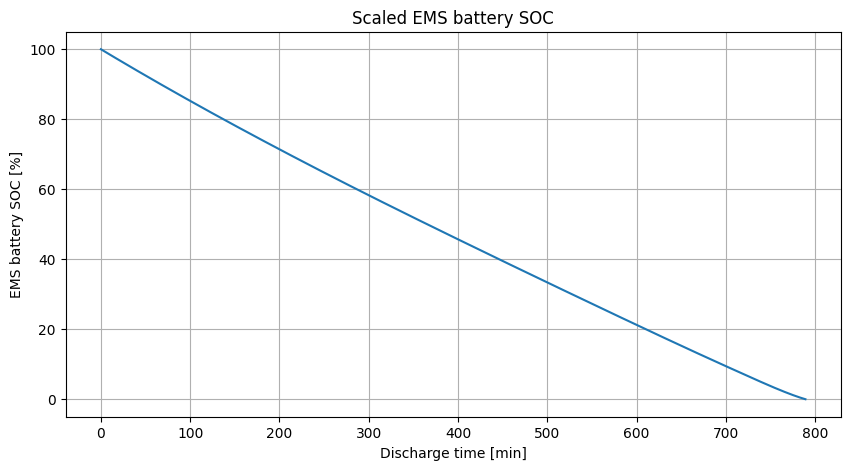

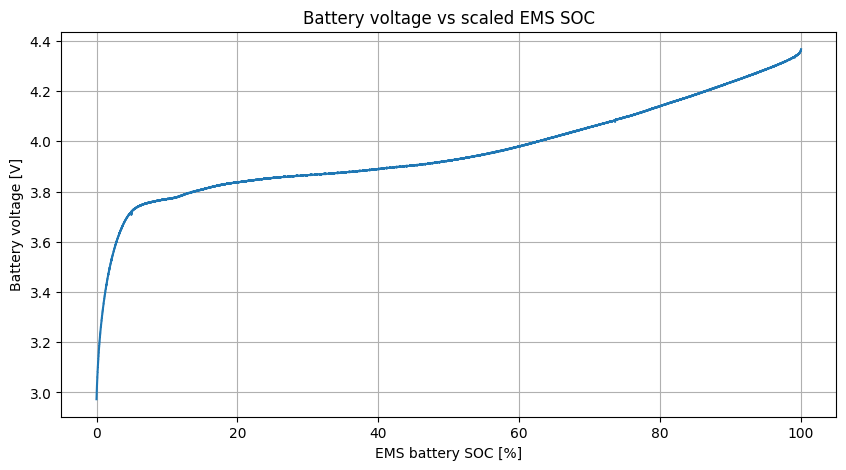

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    discharge["time_discharge_min"],
    discharge["ems_soc_percent"],
)

plt.xlabel("Discharge time [min]")
plt.ylabel("EMS battery SOC [%]")
plt.title("Scaled EMS battery SOC")
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    discharge["ems_soc_percent"],
    discharge["voltage_corrected_V"],
)

plt.xlabel("EMS battery SOC [%]")
plt.ylabel("Battery voltage [V]")
plt.title("Battery voltage vs scaled EMS SOC")
plt.grid(True)
plt.show()


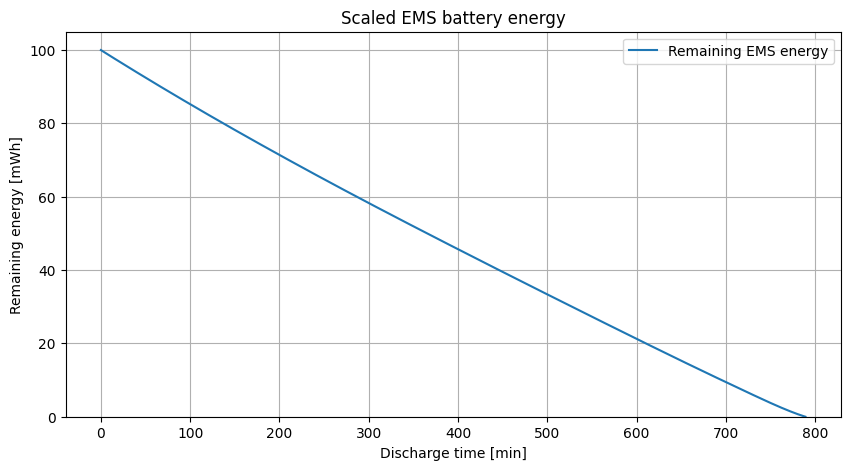

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    discharge["time_discharge_min"],
    discharge["ems_remaining_energy_mWh"],
    label="Remaining EMS energy",
)

plt.xlabel("Discharge time [min]")
plt.ylabel("Remaining energy [mWh]")
plt.title("Scaled EMS battery energy")
plt.grid(True)

plt.ylim(0, EMS_BATTERY_CAPACITY_mWh * 1.05)

plt.legend()
plt.show()


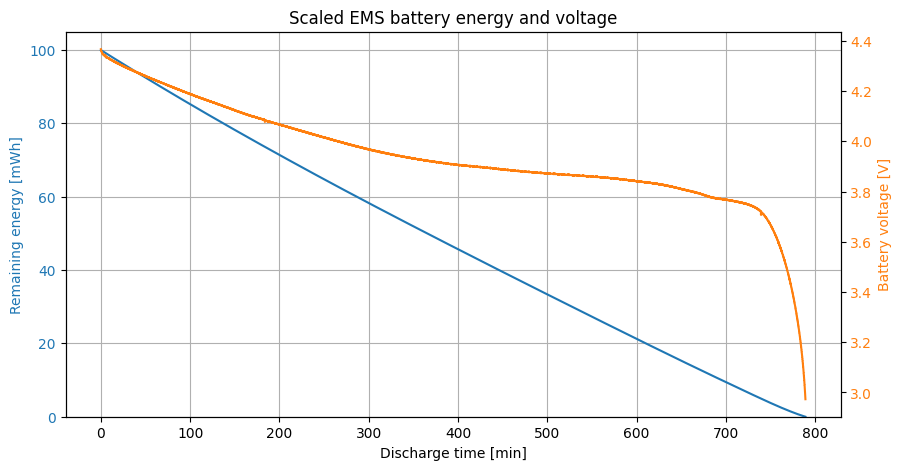

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    discharge["time_discharge_min"],
    discharge["ems_remaining_energy_mWh"],
    color="tab:blue",
    label="Remaining energy",
)

ax1.set_xlabel("Discharge time [min]")
ax1.set_ylabel("Remaining energy [mWh]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, EMS_BATTERY_CAPACITY_mWh * 1.05)
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    discharge["time_discharge_min"],
    discharge["voltage_corrected_V"],
    color="tab:orange",
    label="Battery voltage",
)

ax2.set_ylabel("Battery voltage [V]", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Scaled EMS battery energy and voltage")
plt.show()
